In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import h5py
plt.rcParams["figure.figsize"] = [20, 5]
# Set seed for reproducibility
# np.random.seed(1)
import pandas as pd
import sys
import os

#import inhouse ResComp
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "rescomp", "rescomp")))
import ResComp
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "utils")))
import file_io
from helper import parse_arguments

### Parameter Initialization

In [3]:
# PARAMETERS FOR RESERVOIR
n = 200
erdos_c = 4
gamma = 10
sigma = 0.012
alpha = 0
p_thin = 0.7
rho = 0.5

mean_degree = erdos_c*(1-p_thin)
if mean_degree < 0.0:
    mean_degree = 0.0


#CONSTRUCTION OF RESERVOIR
rescomp = ResComp.ResComp(res_sz=n, mean_degree=mean_degree, 
                                ridge_alpha=alpha, spect_rad=rho, sigma=sigma, 
                                gamma=gamma, map_initial='activ_f')

### Getting Graph from the Resevoir Class

<class 'scipy.sparse._csr.csr_matrix'>


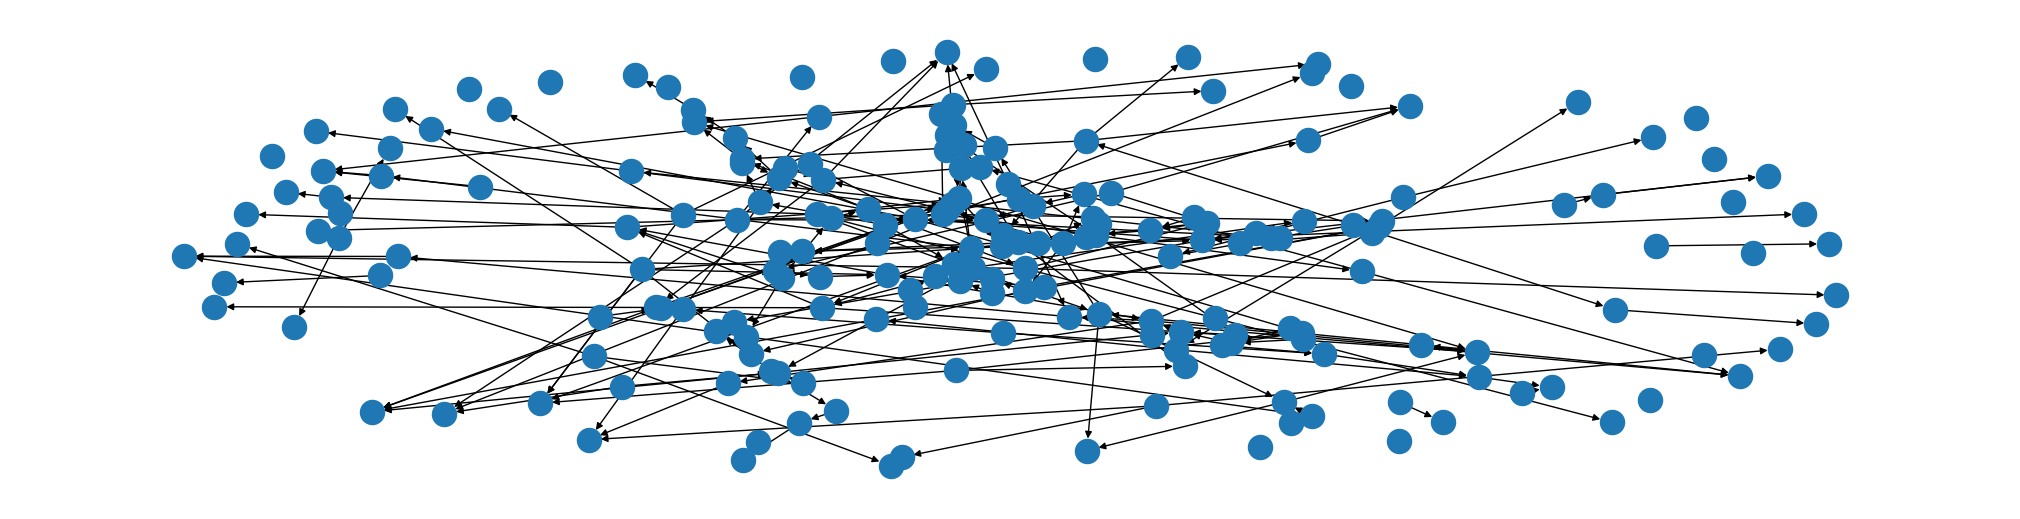

In [4]:
A = rescomp.res
print(type(A))
G = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
nx.draw(G)
plt.show()

### Getting the Degree Sequence (in/out)

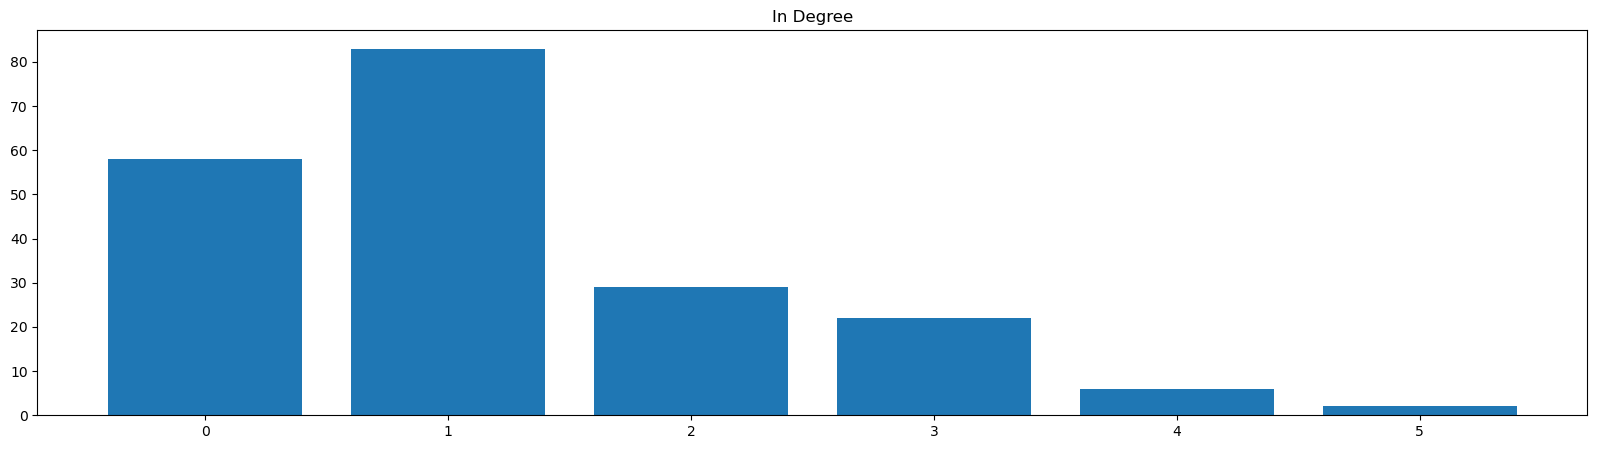

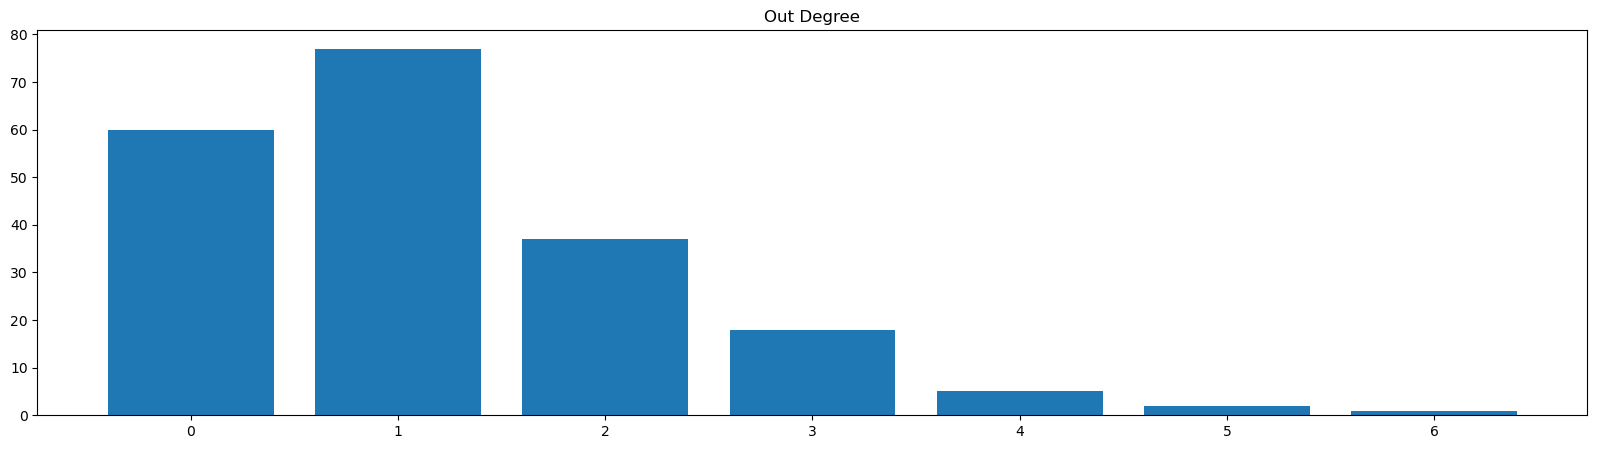

In [5]:
in_deg_sequence = list(dict(G.in_degree()).values())
out_deg_sequence = list(dict(G.out_degree()).values())
plt.bar(*np.unique(in_deg_sequence, return_counts=True))
plt.title("In Degree")
plt.show()

plt.bar(*np.unique(out_deg_sequence, return_counts=True))
plt.title("Out Degree")
plt.show()


### Getting Component Size Distribution

In [6]:
component_sizes = np.array([len(component) for component in nx.strongly_connected_components(G)])
print(component_sizes)
print(component_sizes.max())


[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  3  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  3  1  1 56  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
56


### Get Fraction Driving
**Definition:** a node $u$ is defined to be driving another node $v$ $:=$ $u$ is not in the strongly connected component of $v$ but $(u,v) \in E$

In [7]:
def num_driving(G):
    C = nx.condensation(G)  # condensation collapeses a network into its scc and their connections (1 if there is any connection between them)
    node_to_scc = C.graph['mapping']
    drivers = [node_to_scc[u] != node_to_scc[v] for u, v in G.edges()]
    return sum(drivers)

def fraction_driving(G):
    return num_driving(G) / len(G.nodes())

print(fraction_driving(G))
print(num_driving(G))

0.795
159


In [8]:
def test_num_driving():
    # test function for the number driving with a barbell graph
    G = nx.barbell_graph(3, 1)
    G.add_edges_from([(7,8), (8,9), (9, 7)])
    G.remove_edges_from([(2,3), (3, 4)])
    G = nx.DiGraph(G)
    G.add_edges_from([(3, 2), (6, 3), (3, 7)])
    assert num_driving(G) == 3
    assert fraction_driving(G) == 3/10

test_num_driving()

### Getting Max Diameter (Directed and Undirected)



In [9]:
#get diameter of largest connected component
component_function = nx.strongly_connected_components if nx.is_directed(G) else nx.connected_components
max_component = max(component_function(G), key=len)
diameter = nx.diameter(G.subgraph(max_component))
print(diameter)

27


### Getting the log_transitivity (Clustering Coefficient but scaled so that the small numbers are more meaningful and flip the the negative sign for convention) (directed) (maybe switch to negative log transitivity as an information measure??)

In [10]:
clustering_coeff = np.log(nx.transitivity(G))
print(clustering_coeff)

-4.6443908991413725


### Reading and Writing using the file format


In [11]:
handler = file_io.HDF5FileHandler(file_path="test_file")

with handler:
    handler.add_attr('test_attribute', 1)
    handler.save_attrs()
    group_handler = handler.get_group_handler("test_group1")
    group_handler.add_datasets(testdata = np.arange(10))
    group_handler.add_attrs(mean_testdata = np.arange(10).mean())
    group_handler.save_data()

    group_handler = handler.get_group_handler("test_group2")
    group_handler.add_datasets(testdata = np.arange(20))
    group_handler.add_attrs(mean_testdata = np.arange(20).mean())
    group_handler.save_data()


file_path = 'test_file.h5'
lists = {}
with h5py.File(file_path) as file:
    for group_name in file.keys():
        group = file[group_name]
        for attribute in group.attrs:
            if attribute in lists.keys():
                lists[attribute].append(group.attrs[attribute])
            else:
                lists[attribute] = [group.attrs[attribute]]

print(lists)









{'mean_testdata': [np.float64(4.5), np.float64(9.5)]}


In [12]:
try:
    handler = file_io.HDf5FileHandler(file_path="")

finally:
    handler.close_file()

AttributeError: module 'file_io' has no attribute 'HDf5FileHandler'

In [ ]:
a = {}
if a.keys():
    print('1')

In [ ]:
x = np.arange(9).reshape(3,3)
print(x)
print(x.flatten())

[[0 1 2]
 [3 4 5]
 [6 7 8]]
[0 1 2 3 4 5 6 7 8]


In [ ]:

df = pd.read_csv(f'./utils/param_sets/attractor_recon_set_n_500_c_4.csv')
c = df['erdos_renyi_c'][0]
print(c)

4.0


### SCC Picture

/tmp/ipykernel_505424/1297679831.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('Set1')


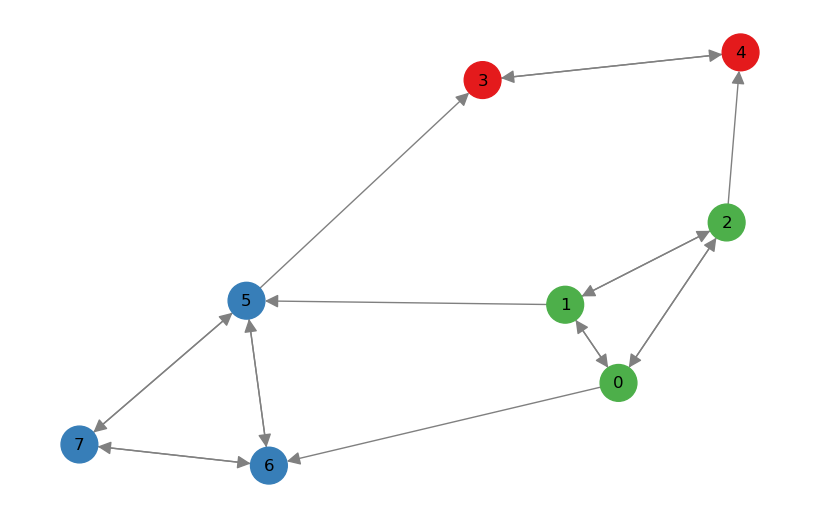

In [ ]:
G = nx.DiGraph()

# SCC 1: nodes 0-3 (fully connected)
scc1 = [0, 1, 2]
for u in scc1:
    for v in scc1:
        if u != v:
            G.add_edge(u, v)

# SCC 2: nodes 4-7 (fully connected)
scc2 = [3, 4]
for u in scc2:
    for v in scc2:
        if u != v:
            G.add_edge(u, v)

# SCC 3: nodes 8-11 (fully connected)
scc3 = [5, 6, 7]
for u in scc3:
    for v in scc3:
        if u != v:
            G.add_edge(u, v)

# Add some directed edges between SCCs
G.add_edge(1, 5)
G.add_edge(2, 4)   # SCC1 → SCC3
G.add_edge(0, 6) 
G.add_edge(5, 3) 

# Find strongly connected components
sccs = list(nx.strongly_connected_components(G))

# Assign a unique color to each SCC
colors = {}
color_map = plt.cm.get_cmap('Set1')
for idx, scc in enumerate(sccs):
    for node in scc:
        colors[node] = color_map(idx)

# Prepare node colors
node_colors = [colors[node] for node in G.nodes()]

# Draw the graph
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G, seed=42)  # layout for better separation
nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color='gray', arrowsize=20, node_size=700)
plt.show()

Graph diameter: 4, between nodes (2, 3)


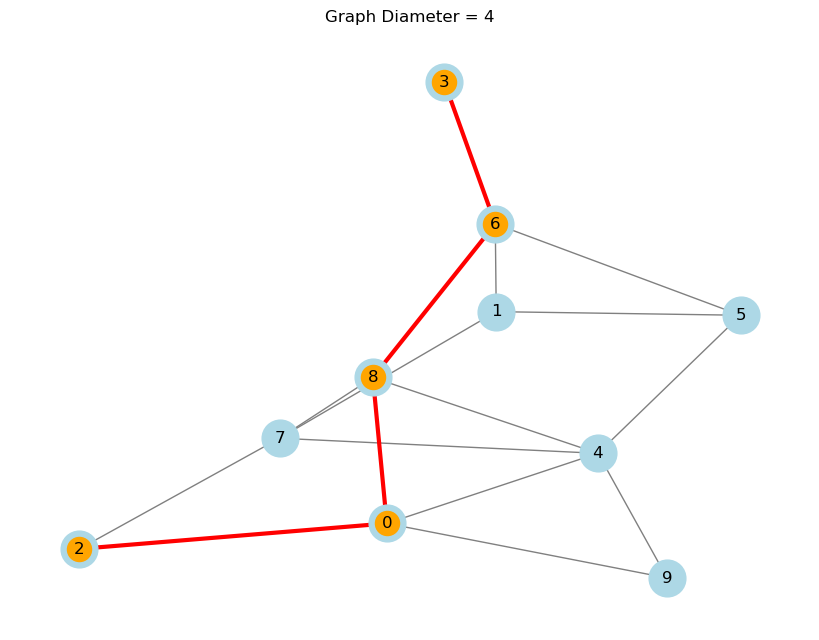

In [ ]:
G = nx.gnp_random_graph(10, 0.3, directed=False)  # undirected for diameter

# Compute all pairs shortest paths
lengths = dict(nx.all_pairs_shortest_path_length(G))

# Find the pair with the longest shortest path (graph diameter)
max_len = 0
max_pair = (None, None)
for u in lengths:
    for v, d in lengths[u].items():
        if d > max_len:
            max_len = d
            max_pair = (u, v)

print(f"Graph diameter: {max_len}, between nodes {max_pair}")

# Get the path corresponding to the diameter
diameter_path = nx.shortest_path(G, source=max_pair[0], target=max_pair[1])

# Draw the graph
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

# Draw all nodes and edges lightly
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700)

# Highlight the diameter path
nx.draw_networkx_nodes(G, pos, nodelist=diameter_path, node_color='orange')
nx.draw_networkx_edges(G, pos, edgelist=list(zip(diameter_path, diameter_path[1:])), width=3, edge_color='red')

plt.title(f"Graph Diameter = {max_len}")
plt.show()

Largest SCC diameter: 3, between nodes (0, 3)


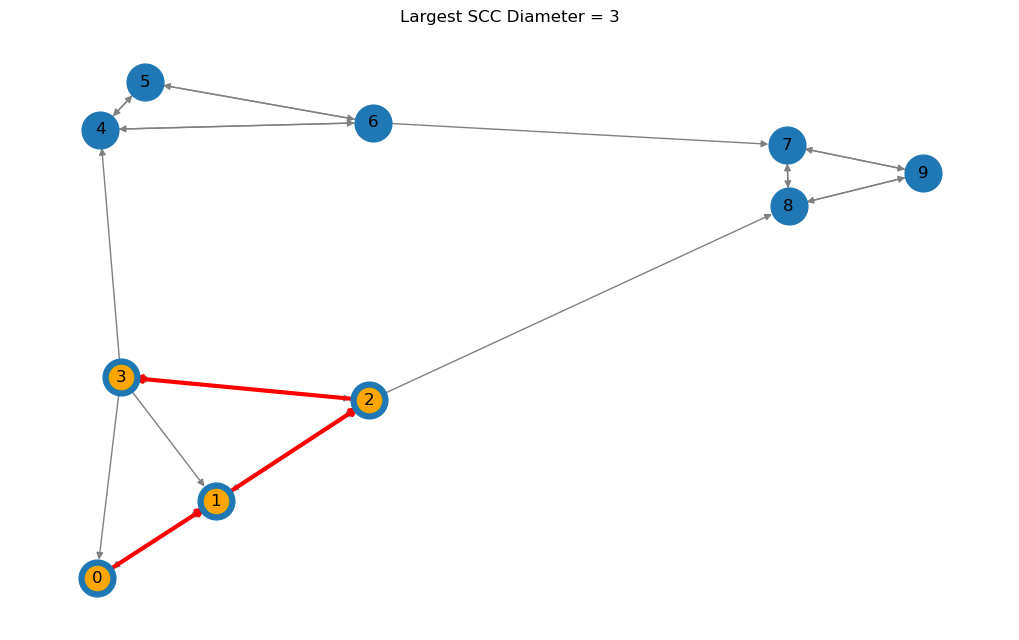

In [ ]:
# Create directed graph
G = nx.DiGraph()

# ===== SCC 1 (diameter = 3) =====
# Nodes 0,1,2,3
# Path: 0->1->2->3 and fully connected back edges to make it strongly connected
scc1 = [0, 1, 2, 3]
G.add_edges_from([
    (0,1), (1,2), (2,3),  # linear chain gives diameter 3
    (1,0), (2,0), (3,0),  # back edges to make it strongly connected
    (2,1), (3,1), (3,2)   # more back edges to ensure SCC
])

# ===== SCC 2 (fully connected, small diameter) =====
scc2 = [4, 5, 6]
for u in scc2:
    for v in scc2:
        if u != v:
            G.add_edge(u,v)

# ===== SCC 3 (fully connected, small diameter) =====
scc3 = [7, 8, 9]
for u in scc3:
    for v in scc3:
        if u != v:
            G.add_edge(u,v)

# ===== Inter-SCC edges =====
G.add_edge(3,4)  # SCC1 -> SCC2
G.add_edge(6,7)  # SCC2 -> SCC3
G.add_edge(2,8)  # SCC1 -> SCC2

# ===== Find largest SCC =====
sccs = list(nx.strongly_connected_components(G))
largest_scc = max(sccs, key=len)
G_scc = G.subgraph(largest_scc).copy()

# ===== Compute diameter of largest SCC =====
lengths = dict(nx.all_pairs_shortest_path_length(G_scc))
max_len = 0
max_pair = (None, None)
for u in lengths:
    for v, d in lengths[u].items():
        if d > max_len:
            max_len = d
            max_pair = (u,v)

print(f"Largest SCC diameter: {max_len}, between nodes {max_pair}")

# Get the path for diameter
diameter_path = nx.shortest_path(G_scc, source=max_pair[0], target=max_pair[1])

# ===== Draw the graph =====
plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, seed=10)

# Draw all nodes lightly
nx.draw(G, pos, with_labels=True, node_color='tab:blue', edge_color='gray', node_size=700)

# Highlight nodes in largest SCC
nx.draw_networkx_nodes(G, pos, nodelist=largest_scc, node_color='tab:green')

# Highlight diameter path
nx.draw_networkx_nodes(G, pos, nodelist=diameter_path, node_color='orange')
nx.draw_networkx_edges(G, pos, edgelist=list(zip(diameter_path, diameter_path[1:])), width=3, edge_color='red')

plt.title(f"Largest SCC Diameter = {max_len}")
plt.show()

Graph transitivity: 0.60


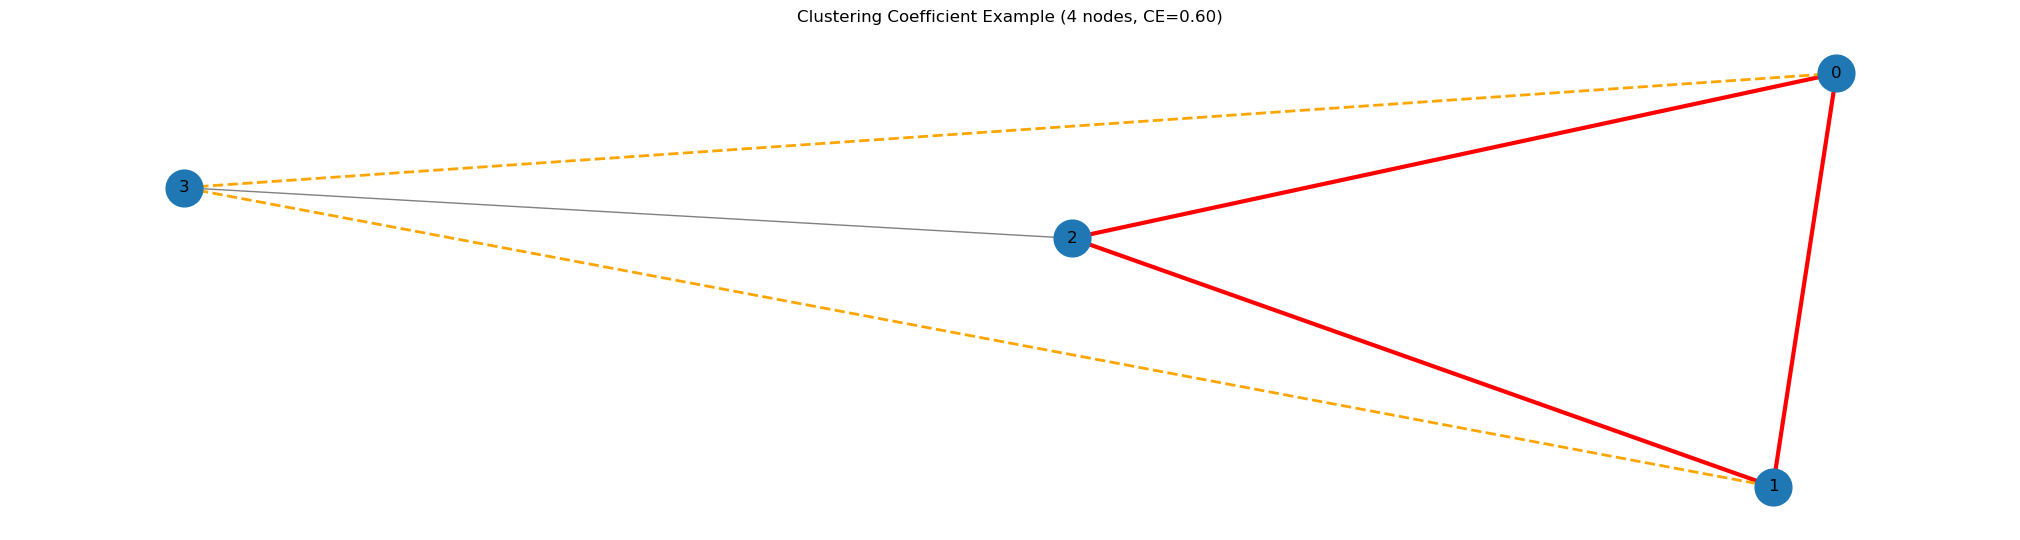

In [ ]:
# Create a small undirected graph with 4 nodes
G = nx.Graph()

# Add edges
edges = [
    (0, 1), (1, 2), (2, 0),  # Triangle (closed triplet)
    (2, 3)                     # Open triplet (2-3 connected but 0-3 missing)
]
G.add_edges_from(edges)

# Compute transitivity
trans = nx.transitivity(G)
print(f"Graph transitivity: {trans:.2f}")

# Find triangles
triangles = [list(tri) for tri in nx.enumerate_all_cliques(G) if len(tri) == 3]

# Layout
pos = nx.spring_layout(G, seed=42)

# Draw all nodes and edges
nx.draw(G, pos, with_labels=True, node_color='tab:blue', edge_color='gray', node_size=700)
edges = [
    (3, 0),  # Triangle (closed triplet)
    (3, 1)                     # Open triplet (2-3 connected but 0-3 missing)
]
G.add_edges_from(edges)

# Highlight triangles in red
for tri in triangles:
    nx.draw_networkx_edges(G, pos, edgelist=[(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])],
                           width=3, edge_color='red')

# Highlight open triplet edges in dashed style
open_triplet_edges = [(3, 0), (3, 1)]
nx.draw_networkx_edges(G, pos, edgelist=open_triplet_edges, width=2, style='dashed', edge_color='orange')

plt.title(f"Clustering Coefficient Example (4 nodes, CE={trans:.2f})")
plt.show()

Number of driving edges: 2
Fraction driving: 0.22


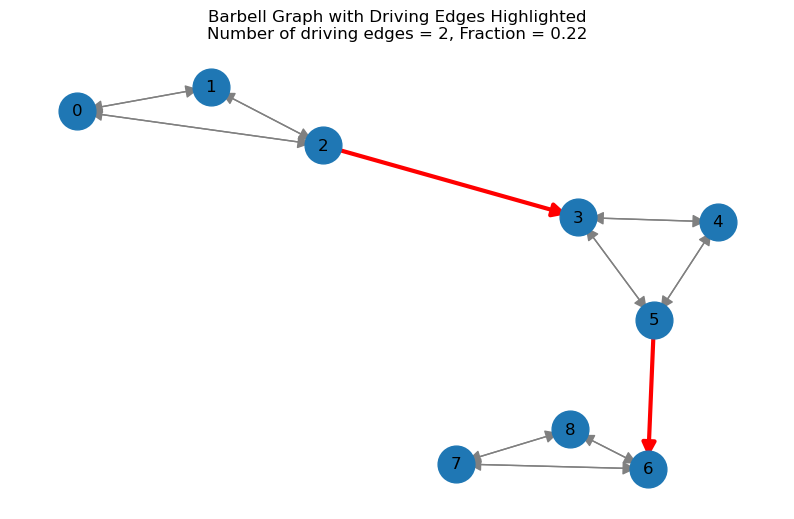

In [ ]:
# ===== Create a custom barbell-like directed graph =====
G = nx.DiGraph()

# SCC 1 (nodes 0,1,2, fully connected)
scc1 = [0,1,2]
for u in scc1:
    for v in scc1:
        if u != v:
            G.add_edge(u,v)

# SCC 2 (nodes 3,4,5, fully connected)
scc2 = [3,4,5]
for u in scc2:
    for v in scc2:
        if u != v:
            G.add_edge(u,v)

# SCC 3 (nodes 6,7,8, fully connected)
scc3 = [6,7,8]
for u in scc3:
    for v in scc3:
        if u != v:
            G.add_edge(u,v)

# Add edges between SCCs (driving edges)
G.add_edge(2,3)  # SCC1 -> SCC2
G.add_edge(5,6)  # SCC2 -> SCC3

# ===== Functions to compute driving edges =====
def num_driving(G):
    C = nx.condensation(G)
    node_to_scc = C.graph['mapping']
    drivers = [node_to_scc[u] != node_to_scc[v] for u,v in G.edges()]
    return sum(drivers)

def fraction_driving(G):
    return num_driving(G) / len(G.nodes())

print(f"Number of driving edges: {num_driving(G)}")
print(f"Fraction driving: {fraction_driving(G):.2f}")

# ===== Identify driving edges =====
C = nx.condensation(G)
node_to_scc = C.graph['mapping']
driving_edges = [(u,v) for u,v in G.edges() if node_to_scc[u] != node_to_scc[v]]
non_driving_edges = [(u,v) for u,v in G.edges() if node_to_scc[u] == node_to_scc[v]]

# ===== Draw the graph =====
plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='tab:blue', node_size=700)

# Draw non-driving edges in gray
nx.draw_networkx_edges(G, pos, edgelist=non_driving_edges, edge_color='gray', arrowsize=20)

# Draw driving edges in red
nx.draw_networkx_edges(G, pos, edgelist=driving_edges, edge_color='red', width=3, arrowsize=20)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12)

plt.title(f"Barbell Graph with Driving Edges Highlighted\nNumber of driving edges = {num_driving(G)}, Fraction = {fraction_driving(G):.2f}")
plt.axis('off')
plt.show()

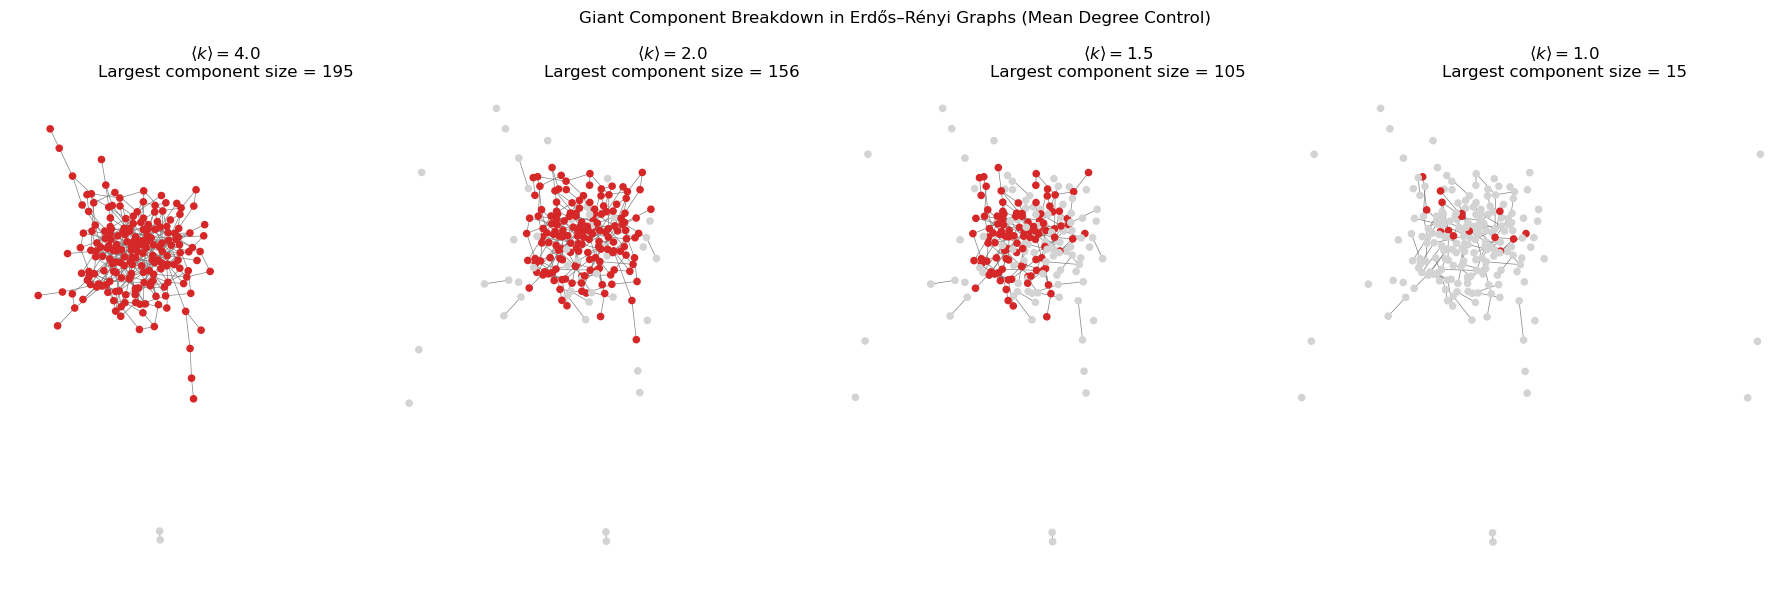

In [23]:
n = 200
mean_degrees = [4.0, 2.0, 1.5, 1.0]   # above, near, below critical value <k>=1
ps = [k / (n - 1) for k in mean_degrees]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Fixed layout for visual consistency
G_layout = nx.erdos_renyi_graph(n, ps[0], seed=42)
pos = nx.spring_layout(G_layout, seed=42)

for ax, k, p in zip(axes, mean_degrees, ps):
    G = nx.erdos_renyi_graph(n, p, seed=42)

    # Largest connected component
    components = list(nx.connected_components(G))
    giant = max(components, key=len)

    node_colors = [
        "tab:red" if node in giant else "lightgray"
        for node in G.nodes()
    ]

    nx.draw(
        G,
        pos=pos,
        ax=ax,
        node_size=20,
        node_color=node_colors,
        edge_color="gray",
        width=0.5
    )

    ax.set_title(
        rf"$\langle k \rangle = {k}$" + "\n"
        + f"Largest component size = {len(giant)}"
    )
    ax.set_axis_off()

plt.suptitle("Giant Component Breakdown in Erdős–Rényi Graphs (Mean Degree Control)")
plt.tight_layout()
plt.show()

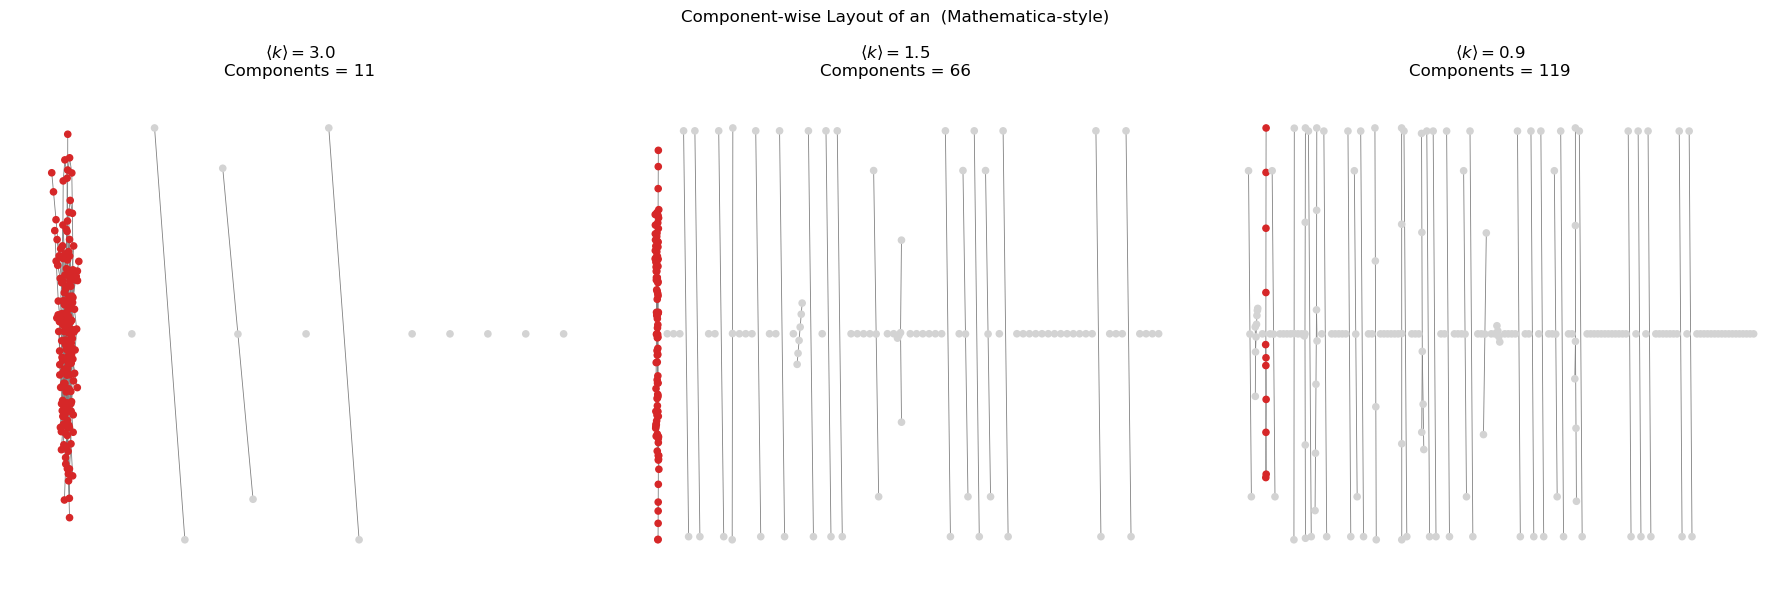

In [26]:
def component_layout(G, spacing=3.0, seed=0):
    """
    Lay out each connected component separately and
    shift them so they do not overlap.
    """
    pos = {}
    x_offset = 0.0

    for component in nx.connected_components(G):
        H = G.subgraph(component)

        # Spring layout for this component
        local_pos = nx.spring_layout(H, seed=seed)

        # Compute bounding box
        xs = np.array([p[0] for p in local_pos.values()])
        width = xs.max() - xs.min()

        # Shift component horizontally
        for node, (x, y) in local_pos.items():
            pos[node] = (x + x_offset, y)

        x_offset += width + spacing

    return pos


# Parameters
n = 200
mean_degrees = [3.0, 1.5, 0.9]   # above, critical, below
ps = [k / (n - 1) for k in mean_degrees]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, k, p in zip(axes, mean_degrees, ps):
    G = nx.erdos_renyi_graph(n, p, seed=42)

    pos = component_layout(G, spacing=2.5, seed=42)

    # Color by component size (giant highlighted)
    components = list(nx.connected_components(G))
    giant = max(components, key=len)

    node_colors = [
        "tab:red" if node in giant else "lightgray"
        for node in G.nodes()
    ]

    nx.draw(
        G,
        pos=pos,
        ax=ax,
        node_size=20,
        node_color=node_colors,
        edge_color="gray",
        width=0.6
    )

    ax.set_title(
        rf"$\langle k \rangle = {k}$" + "\n"
        + f"Components = {len(components)}"
    )
    ax.set_axis_off()

plt.suptitle(
    "Component-wise Layout of an "
    ""
    " (Mathematica-style)"
)
plt.tight_layout()
plt.show()

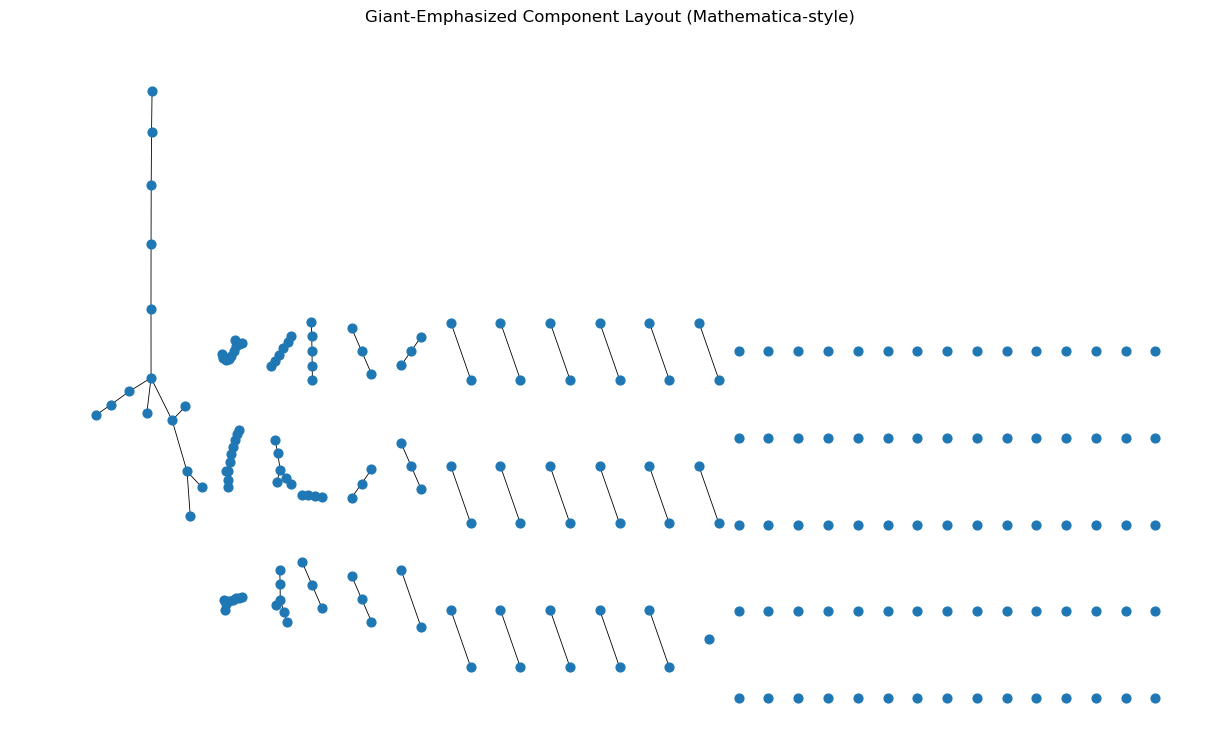

In [ ]:
def component_layout_giant_emphasis(
    G,
    giant_scale=4.0,
    small_scale=0.6,
    padding=1.2,
    seed=None
):
    """
    Layout with lots of space for the giant component
    and compressed space for smaller components.
    """

    pos = {}

    # Sort components by size
    components = sorted(
        nx.connected_components(G),
        key=len,
        reverse=True
    )

    giant = components[0]
    small_components = components[1:]

    # ---- Giant component ----
    H_giant = G.subgraph(giant)
    giant_pos = nx.spring_layout(H_giant, seed=seed)

    for node, (x, y) in giant_pos.items():
        pos[node] = (giant_scale * x, giant_scale * y)

    # Determine bounding box of giant
    xs = np.array([p[0] for p in pos.values()])
    x_max = xs.max()

    # ---- Small components (packed tightly) ----
    x_cursor = x_max + padding
    y_cursor = 0.0
    row_height = 0.0

    for comp in small_components:
        H = G.subgraph(comp)
        local_pos = nx.spring_layout(H, seed=seed)

        xs = np.array([p[0] for p in local_pos.values()])
        ys = np.array([p[1] for p in local_pos.values()])

        width = (xs.max() - xs.min()) * small_scale
        height = (ys.max() - ys.min()) * small_scale

        # Wrap small components vertically
        if y_cursor - height < -6:
            y_cursor = 0.0
            x_cursor += width + padding
            row_height = 0.0

        for node, (x, y) in local_pos.items():
            pos[node] = (
                x_cursor + small_scale * x,
                y_cursor + small_scale * y
            )

        y_cursor -= height + padding
        row_height = max(row_height, height)

    return pos


# ------------------- Dem----------------

n = 200
k = 0.99
p = k / (n - 1)

G = nx.erdos_renyi_graph(n, p, seed=42)

pos = component_layout_giant_emphasis(
    G,
    giant_scale=4.5,
    small_scale=0.5,
    padding=1.5,
    seed=42
)

giant = max(nx.connected_components(G), key=len)
node_colors = [
    "tab:red" if v in giant else "lightgray"
    for v in G.nodes()
]

plt.figure(figsize=(12, 7))
nx.draw(
    G,
    pos=pos,
    node_size=40,
    width=0.6
)
plt.title("Giant-Emphasized Component Layout (Mathematica-style)")
plt.axis("off")
plt.show()